# Homework: Linear Regression vs. Poisson GLM for Count Data
## Machine Learning Methods in Econometrics

In many real-world applications, the variable of interest is a **count** rather than a continuous quantity. Examples include the number of customer arrivals, insurance claims, equipment failures, and bicycle rentals. In such settings, standard linear regression may be hard to justify because the response is non-negative, discrete, and often highly skewed.

In this notebook, you will study **daily bicycle rental demand**. Predicting rental counts is important for bike-sharing operators and city planners: it helps them decide how many bicycles should be available, how to allocate bicycles across stations, when maintenance teams are needed, and how weather conditions affect demand.

The goal of this exercise is to compare two approaches for modeling count outcomes:

- a linear regression model under Gaussian assumptions,
- a Poisson generalized linear model (GLM) with a log link.

You should first implement the main steps **yourself**, using only basic numerical tools such as `numpy`. At the end, you will compare your implementation with the output of a standard library.

**Suggested grading: 100 points**
- Section 1. Load and inspect the data: **10 points**
- Section 2. Distribution analysis and KS statistic: **20 points**
- Section 3. Linear regression from scratch: **20 points**
- Section 4. Poisson GLM from scratch: **25 points**
- Section 5. Comparison of the two models: **10 points**
- Section 6. Verification using a library: **15 points**


Student names: Alexis Firome, Salma el Yadouni, Alexandre Lemonnier

Student numbers: 314496, 340859, 423456


## 1. Load and inspect the data [10 points]

The file `daily-bike-share.csv` is provided with the assignment. In this section, load the dataset, inspect the available columns, and choose a set of explanatory variables that you will use throughout the notebook.

A good starting set is:
- `temp`
- `hum`
- `windspeed`
- `workingday`
- `holiday`
- `weathersit`
- `season`

You may also experiment with other variables, but keep your final model interpretable.


In [105]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# Load the dataset from the local CSV file.
data = pd.read_csv("datasets/daily-bike-share.csv")

# TODO: Display the first few rows and inspect the columns.
data.head()


,day,mnth,year,season,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals
0,1,1,2011,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331
1,2,1,2011,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131
2,3,1,2011,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120
3,4,1,2011,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108
4,5,1,2011,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82


In [106]:
print(data['year'].value_counts())
print(data['mnth'].value_counts())
print(data['weathersit'].value_counts())
print(data['season'].value_counts())
data.describe()

year
2012    366
2011    365
Name: count, dtype: int64
mnth
1     62
3     62
5     62
7     62
8     62
10    62
12    62
4     60
6     60
9     60
11    60
2     57
Name: count, dtype: int64
weathersit
1    463
2    247
3     21
Name: count, dtype: int64
season
3    188
2    184
1    181
4    178
Name: count, dtype: int64


,day,mnth,year,season,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,15.738714,6.519836,2011.500684,2.496580,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471
std,8.809949,3.451913,0.500342,1.110807,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488
min,1.000000,1.000000,2011.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000
25%,8.000000,4.000000,2011.000000,2.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000
50%,16.000000,7.000000,2012.000000,3.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000
75%,23.000000,10.000000,2012.000000,3.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000
max,31.000000,12.000000,2012.000000,4.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000


In [107]:

# TODO: display the list of columns and the shape of the dataset.
# Your code here
print("The colums of the dataset are ", data.columns.tolist())
print("The shape of the dataset is ", data.shape)

The colums of the dataset are  ['day', 'mnth', 'year', 'season', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'rentals']
The shape of the dataset is  (731, 13)


Throughout the notebook, let the response variable be `rentals`, the daily number of bicycle rentals. Since this is a count outcome, it is natural to ask whether a Gaussian model is appropriate or whether a count-data model may be more suitable.


In [108]:

# TODO: define the response vector y and a design matrix X based on your chosen variables.
# Hint: keep a copy of the names of the selected features in a Python list.

feature_names = [
    "temp", "hum", "windspeed", "workingday", "holiday", "weathersit", "season"
]

# X_raw should contain only the selected explanatory variables.
X_raw = data[feature_names].copy()

# y should contain the rental counts.
y = data['rentals']

# Display the first rows of X_raw if you want to inspect your chosen variables.
X_raw.head()

,temp,hum,windspeed,workingday,holiday,weathersit,season
0,0.344167,0.805833,0.160446,0,0,2,1
1,0.363478,0.696087,0.248539,0,0,2,1
2,0.196364,0.437273,0.248309,1,0,1,1
3,0.200000,0.590435,0.160296,1,0,1,1
4,0.226957,0.436957,0.186900,1,0,1,1


## 2. Distribution analysis and KS statistic [20 points]

Before fitting any model, study the distribution of the response variable.

A first question is whether the response looks approximately Gaussian. Since linear regression is commonly motivated by Gaussian errors and symmetric continuous outcomes, this is an important diagnostic step. Here you will:

1. inspect the distribution of `rentals`,
2. standardize the response,
3. compute the Kolmogorov--Smirnov statistic against the standard normal distribution.

Recall that if $z_{(1)} \leq \cdots \leq z_{(n)}$ are the ordered standardized observations, the KS statistic is

$$
D_n = \max\left\{
\max_i \left(\frac{i}{n} - \Phi(z_{(i)})\right),
\max_i \left(\Phi(z_{(i)}) - \frac{i-1}{n}\right)
\right\},
$$

where $\Phi$ is the cdf of the standard normal distribution.


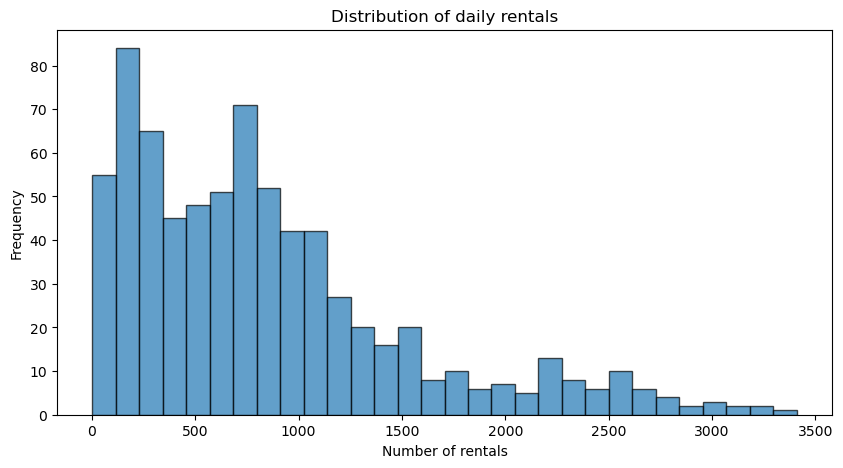

In [109]:

# TODO: plot a histogram of `rentals`.
# You may use around 30 bins.
# Your code here
plt.figure(figsize=(10,5))
plt.hist(data['rentals'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of daily rentals')
plt.xlabel('Number of rentals')
plt.ylabel('Frequency')
plt.show()

Now standardize the response:

$$
z_i = \frac{y_i - \bar y}{s_y}.
$$

Then sort the standardized values and compute the KS statistic **manually**, without using a built-in KS test function.


In [110]:

# Standardize the response
z = (y - y.mean()) / y.std(ddof=0)
z_sorted = np.sort(z)
n = len(z_sorted)

# TODO: compute the KS statistic D_n manually.
# Hint:
#   F_emp_upper at z_(i) is (i+1)/n in Python indexing,
#   F_emp_lower at z_(i) is i/n,
#   F_theory is norm.cdf(z_sorted[i]).

Dn = None

# Your code here

i = np.arange(n)

F_theory = norm.cdf(z_sorted[i])
F_emp_upper = (i + 1) / n
F_emp_lower = i/n

Dn = np.max(np.maximum(F_emp_upper - F_theory, F_theory - F_emp_lower))

print("KS statistic:", Dn)


KS statistic: 0.11356910541361542


Briefly comment on the result. Does the empirical distribution of `rentals` look close to a Gaussian distribution? What does this suggest about the suitability of linear regression as a primary model?


It could look like a Gaussian distribution but it is non-negative and heavily on the right which means that it deviates pretty significantly from a Gaussian distribution. The KS statistic is also high which confirm that deviation from a Gaussian distribution.  
About the suitability of linear regression as a primary model, it suggests that it may be non optimal because it could predict negative rental counts which is impossible.

Before fitting any model, split the sample into a training set and a test set.

Use:
- **80% of the observations for training**, and
- **20% for testing**.

To make your results reproducible, use a fixed random seed. You may generate a random permutation of the row indices and then assign the first 80% to the training set and the remaining 20% to the test set.

All model fitting in the rest of the notebook should be done **only on the training set**. The final **MAE** and **MSE** must be reported **on the test set**.


In [111]:
# TODO: create an 80/20 train-test split.
# Suggested approach:
# 1. set a random seed,
# 2. randomly permute the row indices,
# 3. use the first 80% for training and the remaining 20% for testing.
np.random.seed(42)  # You can choose any seed you like.

index_randomised = np.random.permutation(len(y))

split_idx = int(0.8 * len(y))
train_idx = index_randomised[:split_idx]
test_idx = index_randomised[split_idx:]

# Create train/test versions of the response for later use.
y_train = y[train_idx]
y_test = y[test_idx]

print("Number of training observations:", len(y_train))
print("Number of test observations:", len(y_test))


Number of training observations: 584
Number of test observations: 147


## 3. Linear regression from scratch [20 points]

As a benchmark, fit a linear regression model using the explanatory variables you selected.

After adding an intercept term, the ordinary least squares estimator is

$$
\hat\beta_{\mathrm{OLS}} = (X_{\mathrm{train}}^\top X_{\mathrm{train}})^{-1} X_{\mathrm{train}}^\top y_{\mathrm{train}}.
$$

In this section, compute the estimator directly using matrix algebra. Do not call a high-level regression-fitting library yet.

Important: fit the model **only on the training set**, then compute predictions on the **test set**.


In [112]:
# TODO:
# Convert the raw feature table into a numeric matrix and add an intercept column.
# If you included categorical variables such as season or weathersit, convert them to dummies first and call it X_model.

# Your code here

X_model = pd.get_dummies(X_raw, columns=['season', 'weathersit'], drop_first=True, dtype=float)
intercept = np.ones((X_model.shape[0], 1))
X = np.hstack((intercept, X_model.values.astype(float)))

# TODO: use train_idx and test_idx to create design matrices for the train and test sets.
X_train = X[train_idx]
X_test = X[test_idx]

print("Full design matrix shape:", X.shape)
print("Training design matrix shape:", X_train.shape)
print("Test design matrix shape:", X_test.shape)
print("Columns used in the design matrix:")
print(["const"] + X_model.columns.tolist())


Full design matrix shape: (731, 11)
Training design matrix shape: (584, 11)
Test design matrix shape: (147, 11)
Columns used in the design matrix:
['const', 'temp', 'hum', 'windspeed', 'workingday', 'holiday', 'season_2', 'season_3', 'season_4', 'weathersit_2', 'weathersit_3']


In [113]:
# TODO: compute the OLS estimator beta_ols using only the training set,
# and then compute predictions on both the training and test sets.
# Your code here

beta_ols = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train

y_hat_ols_train = X_train @ beta_ols
y_hat_ols_test = X_test @ beta_ols

print("OLS coefficients:")
print(beta_ols)


OLS coefficients:
[  911.34938212  2118.6862244   -629.39075309 -1114.92016683
  -836.32439626  -256.85585323   260.77312092    -8.06832889
   143.11606816   -32.98980154  -251.20296142]


In [114]:
# TODO: compute two prediction metrics for OLS on the TEST set:
# - mean squared error
# - mean absolute error
#
# You may also compute training-set metrics if you wish, but the reported
# predictive comparison should be based on the test set.

mse_ols_test = np.mean((y_test - y_hat_ols_test)**2)
mae_ols_test = np.mean(np.abs(y_test - y_hat_ols_test))

mse_ols_train = np.mean((y_train - y_hat_ols_train)**2)
mae_ols_train = np.mean(np.abs(y_train - y_hat_ols_train))

print("MSE test", mse_ols_test)
print("MAE test", mae_ols_test)
print("MSE train", mse_ols_train)
print("MAE train", mae_ols_train)


MSE test 179497.34003626212
MAE test 317.9057101132223
MSE train 150460.6978831975
MAE train 281.61684699483453


After fitting the model, inspect the fitted values. Are any of the **test-set** OLS predictions negative? Why might this be problematic in a count-data application?


In [115]:
n_neg = np.sum(y_hat_ols_test < 0)
print("Percent of negative predictions: {:.2f}%".format(100 * n_neg / len(y_hat_ols_test)))

Percent of negative predictions: 6.12%


As we can see, around 6% of the test-set OLS predictions are negative and this is because there isn't any constraint on the sign of the fitted values for a linear regression. This could be problematic in a count-data application because it couldn't be meaningfull to have a negative number of rentals.

## 4. Poisson GLM from scratch [25 points]

Now fit a Poisson generalized linear model. For each observation $i$, assume

$$
Y_i \sim \mathrm{Poisson}(\mu_i),
\qquad
\mu_i = \exp(x_i^\top \beta).
$$

The log link guarantees that fitted means are positive. The log-likelihood (up to an additive constant) is

$$
\ell(\beta) = \sum_{i=1}^n \left( y_i x_i^\top \beta - \exp(x_i^\top \beta) \right).
$$

Fit this model **using the training set only**, and evaluate its predictive accuracy on the **test set**.


In [116]:
# TODO: implement Newton iterations for the Poisson log-likelihood on the TRAINING set.
# Suggested initialization: beta = np.zeros(X_train.shape[1])
# Suggested stopping rule: stop when the Euclidean norm of the update is sufficiently small.

beta_pois = np.zeros(X_train.shape[1])

max_iter = 100
tol = 1e-8

beta_pois[0] = np.log(y_train.mean())  

for it in range(max_iter):
    # TODO: compute eta, mu, gradient, Hessian, and the Newton step using X_train and y_train.
    # Then update beta_pois.
    
    # Hint: Since mu = exp(eta), very large or very small eta values can cause
    # numerical overflow or underflow. Clipping eta to a range like [-20, 20]
    # keeps exp(eta) numerically stable.

    eta = np.clip(X_train @ beta_pois, -20, 20)
    mu = np.exp(eta)
    gradient = X_train.T @ (y_train - mu) - alpha * beta_pois
    Hessian = - (X_train.T * mu) @ X_train - alpha * np.eye(X_train.shape[1])
    try:
        step = np.linalg.solve(Hessian, -gradient)
    except np.linalg.LinAlgError:
        step = np.linalg.lstsq(Hessian, -gradient, rcond=None)[0]
        
    beta_pois = beta_pois + lr * step

    # TODO: stopping rule
    if np.linalg.norm(step) < tol:
        break

print("Poisson coefficients:")
print(beta_pois)


Poisson coefficients:
[ 6.17572498  2.48806364 -0.61223801 -1.0188772  -0.86399486 -0.22388819
  0.54439563  0.25427736  0.47874903 -0.06845317 -1.03217339]


In [117]:
# TODO: compute the fitted means for the Poisson model on both train and test sets.
# Then compute MSE and MAE on the TEST set for comparison with OLS.

# Your code here
y_hat_pois_train = np.exp(np.clip(X_train @ beta_pois, -20, 20))
y_hat_pois_test = np.exp(np.clip(X_test @ beta_pois, -20, 20))

mse_pois_test = np.mean((y_test - y_hat_pois_test)**2)
mae_pois_test = np.mean(np.abs(y_test - y_hat_pois_test))

print("MSE test", mse_pois_test)
print("MAE test", mae_pois_test)

MSE test 182725.26485848392
MAE test 292.8723297587857


In [118]:
neg = np.sum(y_hat_pois_test < 0)
print("Percent of negative predictions: {:.2f}%".format(100 * neg / len(y_hat_pois_test)))

Percent of negative predictions: 0.00%


Comment on the fitted values of the Poisson model on the **test set**. In what sense are they more natural for count data than the OLS predictions?


It is more natural because Poisson always produces strictly positive values and then it is much more natural for count data than OLS predictions. 

## 5. Compare the two models [10 points]

In this section, compare the fitted values and prediction quality of the two models. You may compare them numerically and visually.

A useful way to think about the difference is the following:

- OLS models the conditional mean as a linear function of the covariates.
- Poisson GLM models the conditional mean as $\exp(x_i^\top \beta)$.

This difference affects both the sign of the predictions and the way covariates enter the model.


In [119]:
# TODO: print the TEST-SET metrics for both models in a clean format.
# Your code here
print("TEST SET METRICS:")
print("Model\t\tMSE\t\tMAE")
print("OLS\t\t{:.2f}\t{:.2f}".format(mse_ols_test, mae_ols_test))
print("Poisson\t\t{:.2f}\t{:.2f}".format(mse_pois_test, mae_pois_test))


TEST SET METRICS:
Model		MSE		MAE
OLS		179497.34	317.91
Poisson		182725.26	292.87


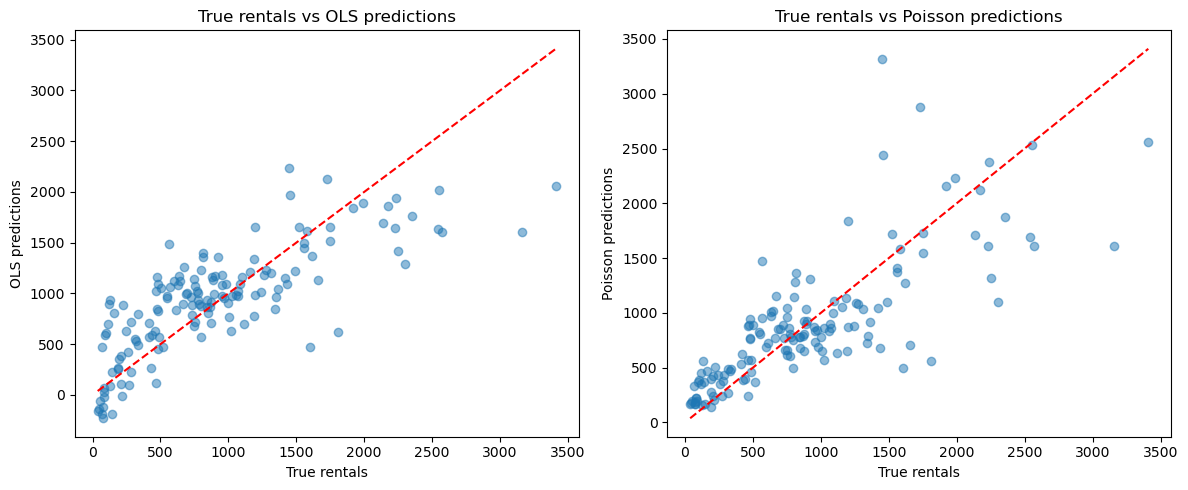

In [120]:
# TODO: make two comparison plots using the TEST set.
# - true rentals versus OLS test predictions
# - true rentals versus Poisson test predictions

# Your code here
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_hat_ols_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('True rentals vs OLS predictions')
plt.xlabel('True rentals')
plt.ylabel('OLS predictions')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_hat_pois_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('True rentals vs Poisson predictions')
plt.xlabel('True rentals')
plt.ylabel('Poisson predictions')
plt.tight_layout()
plt.show()


Based on your implementation, which model appears more appropriate for this application? Give a short explanation based on both the data, the model assumptions, and the **test-set** prediction results.


The model that seems more appropriate is the Poisson because we don't have any negative values. Moreover, there are less outliers in the OLS predictions and that's why the MSE is lower than Poisson but the MAE is higher.
For the data, Poisson is more appropriate because it predicts strictly positive values.

## 6. Verification using a library [15 points]

You have now implemented both models yourself. In this final section, compare your results with standard software.

Use a library implementation to fit:
- a linear regression model,
- a Poisson GLM.

Both library models should be fit on the **same training set** as before. Then compare:
- the estimated coefficients,
- the test-set predictions,
- and the test-set metrics you computed earlier.

Minor differences are acceptable and may arise from numerical optimization details.


In [127]:
import statsmodels.api as sm

# TODO Fit OLS using a library on the TRAINING set.
ols_lib = sm.regression.linear_model.OLS(y_train, X_train).fit()

# TODO Fit Poisson GLM using a library on the TRAINING set.
pois_lib = sm.GLM(y_train, X_train, family=sm.families.Poisson()).fit()

print(ols_lib.summary())
print(pois_lib.summary())


                            OLS Regression Results                            
Dep. Variable:                rentals   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     122.9
Date:                Wed, 25 Mar 2026   Prob (F-statistic):          1.69e-135
Time:                        18:29:50   Log-Likelihood:                -4309.7
No. Observations:                 584   AIC:                             8641.
Df Residuals:                     573   BIC:                             8690.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        911.3494    117.904      7.730      0.0

In [129]:
# TODO: compare your coefficients and TEST-SET predictions with the library results.
# For example, you may compare using:
# - np.max(np.abs(beta_ols - ols_lib.params))
# - np.max(np.abs(beta_pois - pois_lib.params))
# - np.max(np.abs(y_hat_ols_test - ols_lib.predict(X_test)))
# - np.max(np.abs(y_hat_pois_test - pois_lib.predict(X_test)))

# Your code here
y_hat_ols_lib_test = ols_lib.predict(X_test)
y_hat_pois_lib_test = pois_lib.predict(X_test)

print("Max abs difference in OLS coefficients: {:.3f}".format(np.max(np.abs(beta_ols - ols_lib.params))))
print("Max abs difference in Poisson coefficients: {:.3f}".format(np.max(np.abs(beta_pois - pois_lib.params))))
print("Max abs difference in OLS test predictions: {:.3f}".format(np.max(np.abs(y_hat_ols_test - ols_lib.predict(X_test)))))
print("Max abs difference in Poisson test predictions: {:.3f}".format(np.max(np.abs(y_hat_pois_test - pois_lib.predict(X_test)))))


mse_ols_lib_test = np.mean((y_test - y_hat_ols_lib_test)**2)
mae_ols_lib_test = np.mean(np.abs(y_test - y_hat_ols_lib_test))
mse_pois_lib_test = np.mean((y_test - y_hat_pois_lib_test)**2)
mae_pois_lib_test = np.mean(np.abs(y_test - y_hat_pois_lib_test))

print("OLS lib test: MSE {:.2f}, MAE {:.2f}".format(mse_ols_lib_test, mae_ols_lib_test))
print("Poisson lib test: MSE {:.2f}, MAE {:.2f}".format(mse_pois_lib_test, mae_pois_lib_test))


Max abs difference in OLS coefficients: 0.000
Max abs difference in Poisson coefficients: 0.000
Max abs difference in OLS test predictions: 0.000
Max abs difference in Poisson test predictions: 0.000
OLS lib test: MSE 179497.34, MAE 317.91
Poisson lib test: MSE 182725.27, MAE 292.87


## Final discussion

Write a short concluding paragraph addressing the following points:

1. What did the KS statistic suggest about the distribution of the response?

The KS statistic suggest that the distribution isn't Gaussian and that flagged that linear regression isn't the best choice for this type of predictions

2. What is the main conceptual difference between linear regression and the Poisson GLM in this application?

OLS assumes a possible negative prediction whereas Poisson GLM is strictly positive. 

3. Which model appears more appropriate for predicting bicycle rental counts, and why?

The Poisson because of the reasons mentionned before (non negativity) and because of discrete nature of counts.

4. How close were your manual implementations to the library results?

There are considered as the same according to the result which confirm that it converges to the same solutions. 
